9. This question involves the use of multiple linear regression on the
Auto data set.

(a) Produce a scatterplot matrix which includes all of the variables
in the data set.

In [2]:
#data = pd.read_csv('/content/drive/MyDrive/Auto.csv')
!pip install ISLP
from ISLP import load_data
import seaborn as sns
import matplotlib.pyplot as plt
data = load_data('Auto')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.3 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=6f90fdda3c9bb6607201b3147c031a870a666309ad4af3a11baedfe32502c929
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


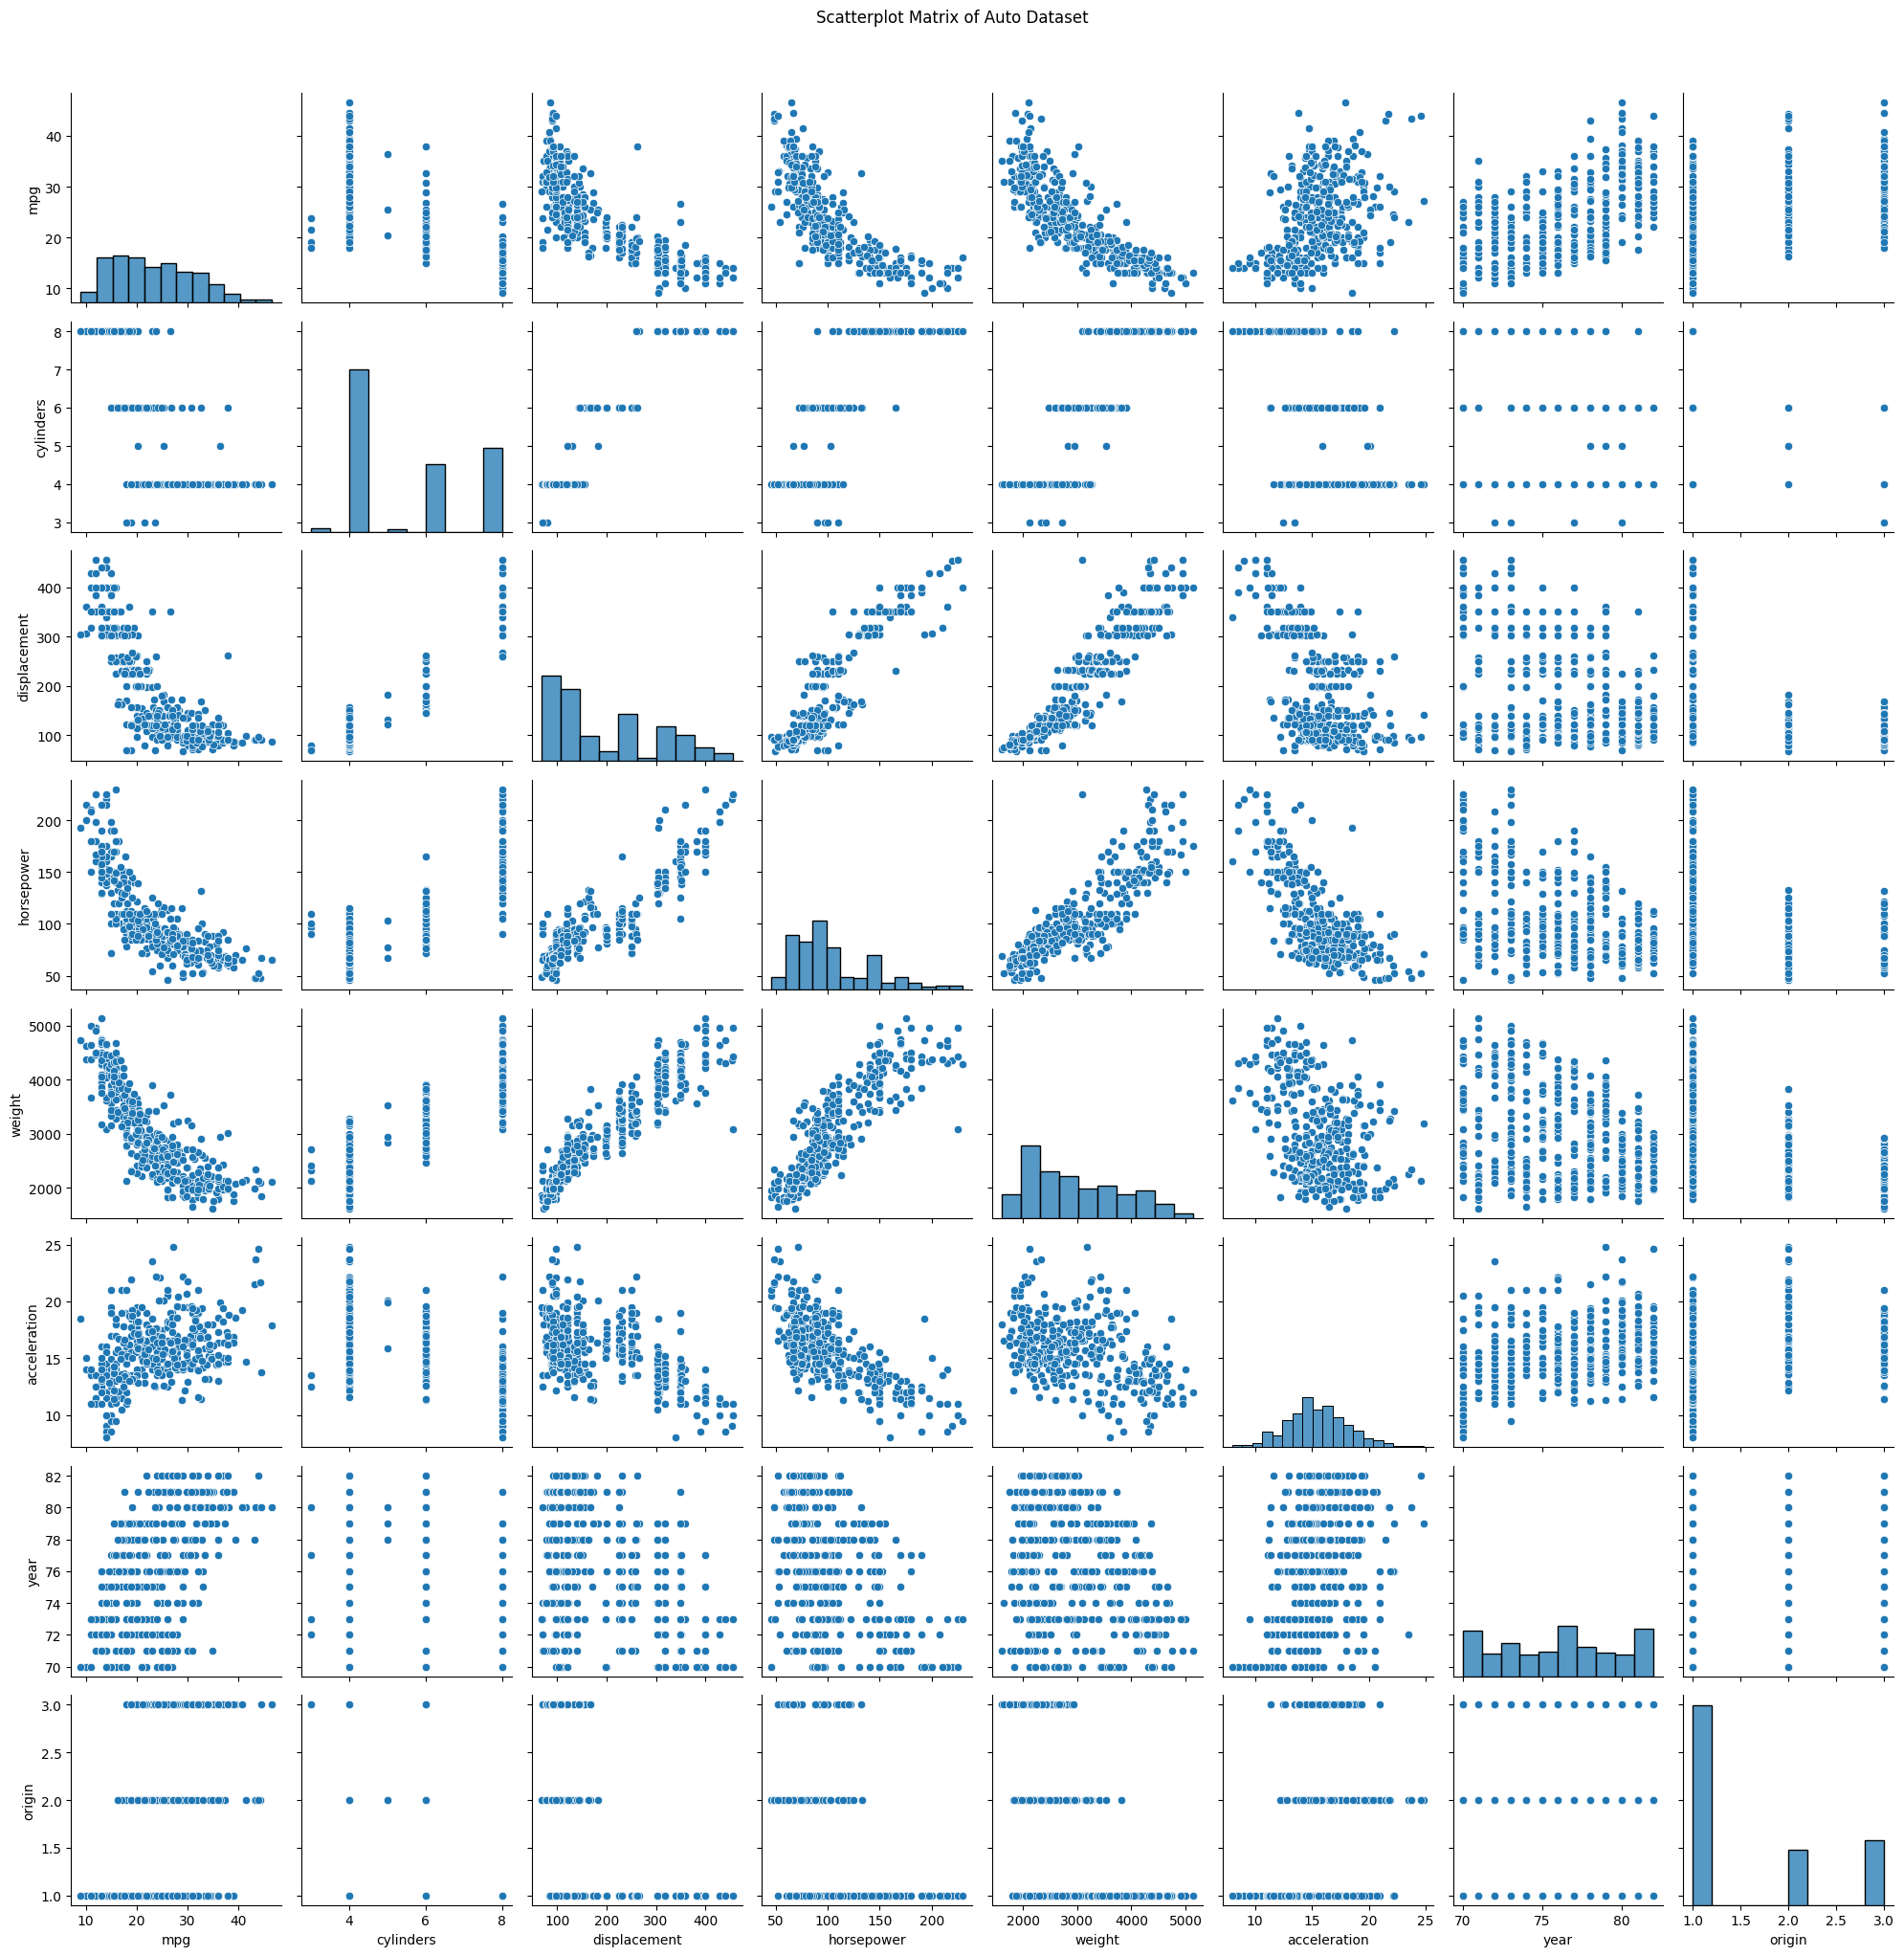

In [3]:
sns.pairplot(data)
plt.suptitle("Scatterplot Matrix of Auto Dataset", y=1.02)
plt.tight_layout()
plt.show()

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, chevrolet chevelle malibu to chevy s-10
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 35.7+ KB


(b) Compute the matrix of correlations between the variables using
the DataFrame.corr() method.

In [6]:
data_num = data.select_dtypes(include='number') #先過濾數值欄位
corr = data_num.corr()
corr

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


(c) Use the sm.OLS() function to perform a multiple linear regression with mpg as the response and all other variables except name as the predictors. Use the summarize() function to print the results. Comment on the output. For instance:


In [7]:
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm

# 過濾掉非數值欄位 name
#dt_num = data.select_dtypes(include='number')
y = data['mpg']
X = data_num.drop(columns=['mpg'])

X = sm.add_constant(X) # 加入截距項
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          2.04e-139
Time:                        16:50:44   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -17.2184      4.644     -3.707   


i. Is there a relationship between the predictors and the response? Use the anova_lm() function from statsmodels to answer this question.

The ANOVA results indicate that cylinders, displacement, horsepower, weight, year, and origin have p-values close to zero, showing that these predictors are significantly related to mpg.

In [9]:
import statsmodels.formula.api as smf
import pandas as pd

# 先把自變數列表生成 formula
#predictors = "+".join(data_num.columns.difference(['mpg']))
#formula = f"mpg ~ {predictors}"
formula = 'mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin'

# 建立回歸模型
model = smf.ols(formula=formula, data=data_num).fit()

# 做 ANOVA
anova_results = anova_lm(model)
pd.options.display.float_format = '{:.6f}'.format
print(anova_results)

                     df       sum_sq      mean_sq           F   PR(>F)
cylinders      1.000000 14403.083079 14403.083079 1300.683788 0.000000
displacement   1.000000  1073.344025  1073.344025   96.929329 0.000000
horsepower     1.000000   403.408069   403.408069   36.430140 0.000000
weight         1.000000   975.724953   975.724953   88.113748 0.000000
acceleration   1.000000     0.966071     0.966071    0.087242 0.767873
year           1.000000  2419.120249  2419.120249  218.460900 0.000000
origin         1.000000   291.134494   291.134494   26.291171 0.000000
Residual     384.000000  4252.212530    11.073470         NaN      NaN


ii. Which predictors appear to have a statistically significant relationship to the response?

-> cylinders, displacement, horsepower, weight, year, and origin

iii. What does the coefficient for the year variable suggest?

-> 0.7703 (Holding other predictors constant, mpg increases by 0.7508 for each additional year)

(d) Produce some of diagnostic plots of the linear regression fit as described in the lab. Comment on any problems you see with the fit. Do the residual plots suggest any unusually large outliers? Does the leverage plot identify any observations with unusually high leverage?

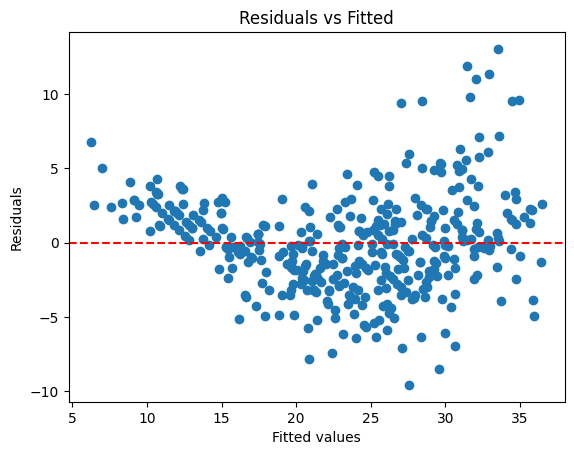

In [10]:
fitted_vals = model.fittedvalues
residuals = model.resid

plt.scatter(fitted_vals, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

####Residuals vs Fitted Plot: The residuals are scattered around the horizontal dashed line at 0. However, the vertical spread of the points seems to increase as the "Fitted values" increase (especially after about 20), forming a slight "cone" shape.

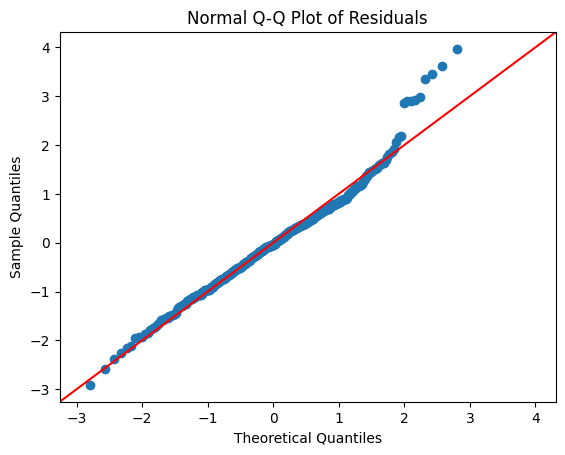

In [11]:
sm.qqplot(residuals, line='45',fit=True)
plt.title("Normal Q-Q Plot of Residuals")
plt.show()

####Q-Q Plot: Points should lie approximately on the diagonal line if residuals are normally distributed. In our plot, most points follow the line well, but there are slight deviations at the tails, suggesting some extreme high value..

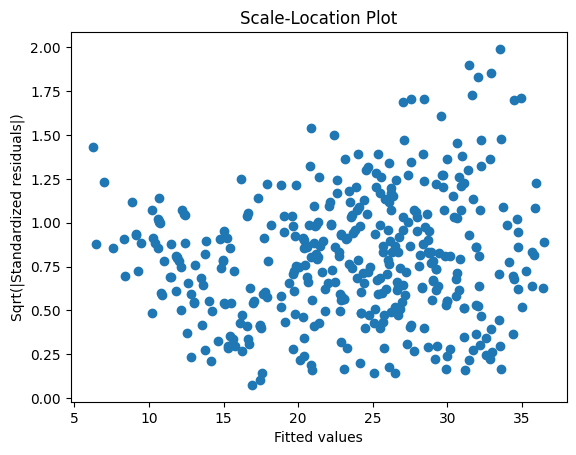

In [12]:
import numpy as np
std_resid = residuals / np.std(residuals)
plt.scatter(fitted_vals, np.sqrt(np.abs(std_resid)))
plt.xlabel("Fitted values")
plt.ylabel("Sqrt(|Standardized residuals|)")
plt.title("Scale-Location Plot")
plt.show()

####The Scale-Location plot suggests mild heteroscedasticity, meaning the residual variance increases slightly for larger fitted values, which could affect the reliability of standard errors and confidence intervals.

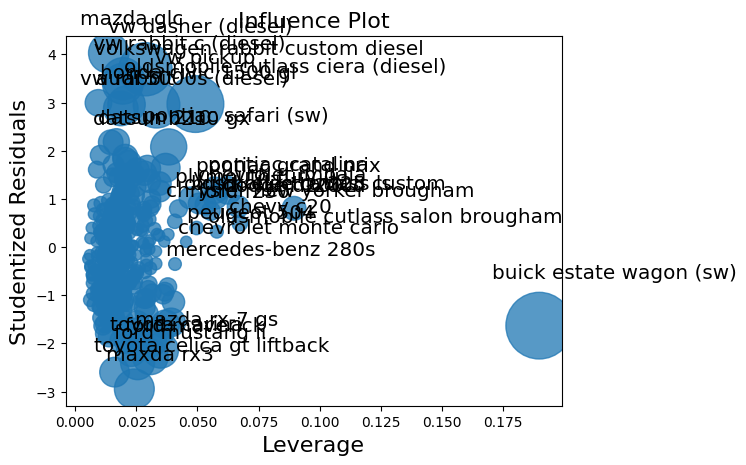

In [13]:
sm.graphics.influence_plot(model, criterion="cooks")
plt.show()

####Influence Plot: Most points cluster with low leverage (X-axis) and Studentized Residuals between -3 and 4. The point labeled "buick estate wagon (sw)" stands out significantly. It has very high leverage (far right on the X-axis) and a moderately large negative Studentized Residual. Its large bubble size indicates it is a highly influential observation.

(e) Fit some models with interactions as described in the lab. Do any interactions appear to be statistically significant?

In [14]:
import statsmodels.formula.api as smf

# 加入 weight 和 year 的交互作用
formula = "mpg ~ weight + year + weight:year"

model_interact = smf.ols(formula=formula, data=data_num).fit()
print(model_interact.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     649.3
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          8.06e-151
Time:                        16:52:42   Log-Likelihood:                -1009.3
No. Observations:                 392   AIC:                             2027.
Df Residuals:                     388   BIC:                             2043.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    -110.4519     12.947     -8.531      

After fitting models with interaction terms, the interaction between weight and year appears statistically significant (p < 0.05), indicating that the effect of weight on mpg depends on the car's year.

In [ ]:
import statsmodels.formula.api as smf

# 加入 displacement 和 cylinders 的交互作用
formula = "mpg ~ displacement * cylinders"

model_interact = smf.ols(formula=formula, data=data_num).fit()
print(model_interact.summary())


In a multiple linear regression model including displacement, cylinders, and their interaction, all coefficients are statistically significant (p < 0.05). The significant displacement:cylinders interaction indicates that the effect of displacement on mpg varies depending on the number of cylinders.

(f) Try a few different transformations of the variables, such as log(X), √X, X². Comment on your findings.

R-squared / Adjusted R-squared

越高 → 模型越能解釋 mpg 變異

In [15]:
predictors = data_num.drop(columns=['mpg']).columns.tolist()

#原始模型
formula_orig = "mpg ~ " + " + ".join(predictors)
model_orig = smf.ols(formula=formula_orig, data=data_num).fit()

#log 轉換（避免 log(0)，加 1）
formula_log = "mpg ~ " + " + ".join([f"np.log({col}+1)" for col in predictors])
model_log = smf.ols(formula=formula_log, data=data_num).fit()

#sqrt 轉換
formula_sqrt = "mpg ~ " + " + ".join([f"np.sqrt({col})" for col in predictors])
model_sqrt = smf.ols(formula=formula_sqrt, data=data_num).fit()

#二次項轉換
formula_quad = "mpg ~ " + " + ".join([f"{col} + I({col}**2)" for col in predictors])
model_quad = smf.ols(formula=formula_quad, data=data_num).fit()

#比較 R-squared
results = pd.DataFrame({
    "Model": ["Original", "Log", "Sqrt", "Quadratic"],
    "R-squared": [model_orig.rsquared, model_log.rsquared, model_sqrt.rsquared, model_quad.rsquared],
    "Adj R-squared": [model_orig.rsquared_adj, model_log.rsquared_adj, model_sqrt.rsquared_adj, model_quad.rsquared_adj]
})

print(results)


       Model  R-squared  Adj R-squared
0   Original   0.821478       0.818224
1        Log   0.847827       0.845053
2       Sqrt   0.833848       0.830820
3  Quadratic   0.879768       0.875304


* The quadratic model (including X² terms) has the highest R-squared and adjusted R-squared, suggesting the best fit.
* Logarithmic and square root transformations slightly improve the model’s explanatory power compared to the original model.
* This indicates that some predictors have non-linear effects on mpg, and including quadratic terms better captures these relationships.
